# Early Student Risk Detection Using OULAD

### An Explainable Machine Learning Approach for Early Academic Intervention

**Dataset:** Open University Learning Analytics Dataset (OULAD) — 32,593 student-course records, 22 course presentations, over 10.6M VLE interactions, and 173,912 assessment submissions.

**Target:**  
- **Not At Risk (0):** Pass or Distinction  
- **At Risk (1):** Fail or Withdrawn

**Goal:** Identify students who may be at risk as early as possible by combining engagement, assessment, and student information, then explain the predictions to support timely and targeted academic intervention.

**Main Early-Warning Point:** Week 4 (Day 28), with additional evaluation at Weeks 2, 6, and 8.

---

## Analysis Roadmap

1. Setup and Data Loading  
2. Data Quality and Cleaning  
3. Binary Risk Target Definition  
4. Early Feature Engineering  
5. Exploratory Analysis and Outlier Detection  
6. Demographic, Engagement, and Assessment Risk Patterns  
7. Early Detection Analysis — Weeks 2, 4, 6, and 8  
8. Baseline and Ensemble Model Comparison  
9. XGBoost Optimization and Group-Aware Validation  
10. Decision Threshold Selection  
11. Final Model Evaluation  
12. SHAP Global and Individual Interpretability  
13. Key Findings and Advisor Recommendations  
14. Limitations and Conclusion

---

### Business Questions
1. Which combination of demographic, academic, and engagement factors best predicts student risk?
2. How early can the model identify an at-risk student using the first few weeks of data?
3. Do age, prior education, or socioeconomic groups show different risk patterns?
4. How does VLE activity relate to student risk?
5. Which early assessments or checkpoints provide the strongest warning signal?
6. For an individual at-risk prediction, what factors drive the prediction and how can an advisor respond?

## 1. Setup and Data Loading

In [ ]:
# Import all libraries in one cell
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, precision_recall_curve
import xgboost as xgb
import shap
sns.set_theme(style='whitegrid', context='notebook')
NOT_RISK_COLOR = '#315A72'
RISK_COLOR = '#B7793F'
ACCENT_COLOR = '#3A7D78'


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')
# Set the OULAD dataset path
DATA_PATH = '/content/drive/MyDrive/SDA/Open University Learning Analytics Dataset (OULAD)/'
print(os.listdir(DATA_PATH))


Mounted at /content/drive
['assessments.csv', 'studentAssessment.csv', 'studentInfo.csv', 'courses.csv', 'studentRegistration.csv', 'studentVle.csv', 'vle.csv', 'SamaherAlsharif_CaseStudy2.ipynb']


In [ ]:
# Load the OULAD tables
student_info = pd.read_csv(DATA_PATH + 'studentInfo.csv')
student_reg = pd.read_csv(DATA_PATH + 'studentRegistration.csv')
student_vle = pd.read_csv(DATA_PATH + 'studentVle.csv')
vle = pd.read_csv(DATA_PATH + 'vle.csv')
student_assessment = pd.read_csv(DATA_PATH + 'studentAssessment.csv')
assessments = pd.read_csv(DATA_PATH + 'assessments.csv')
courses = pd.read_csv(DATA_PATH + 'courses.csv')
KEY = ['code_module', 'code_presentation', 'id_student']


In [ ]:
# Check the shape of each table
datasets = {'studentInfo': student_info, 'studentRegistration': student_reg, 'studentVle': student_vle, 'vle': vle, 'studentAssessment': student_assessment, 'assessments': assessments, 'courses': courses}
for name, data in datasets.items():
    print(f'{name}: {data.shape}')


studentInfo: (32593, 12)
studentRegistration: (32593, 5)
studentVle: (10655280, 6)
vle: (6364, 6)
studentAssessment: (173912, 5)
assessments: (206, 6)
courses: (22, 3)


The OULAD data is stored across several related tables. Student-level, registration, assessment, and VLE activity information are kept separate until the required early features are created.

## 2. Data Quality

In [ ]:
# Summarize missing values in the student-level table
missing_summary = student_info.isna().sum().to_frame('Missing')
missing_summary['Percentage'] = (missing_summary['Missing'] / len(student_info) * 100).round(2)
display(missing_summary[missing_summary['Missing'] > 0])


,Missing,Percentage
imd_band,1111,3.41


 Only `imd_band` has missing values in `studentInfo`: **1,111 records (3.41%)**. It is kept as an `Unknown` category instead of dropping those students.

In [ ]:
# Check exact duplicates in the raw tables
for name, data in datasets.items():
    print(f'{name}: {data.duplicated().sum():,} exact duplicates')


studentInfo: 0 exact duplicates
studentRegistration: 0 exact duplicates
studentVle: 787,170 exact duplicates
vle: 0 exact duplicates
studentAssessment: 0 exact duplicates
assessments: 0 exact duplicates
courses: 0 exact duplicates


In [ ]:
# Remove exact VLE duplicates before calculating engagement
vle_duplicate_count = student_vle.duplicated().sum()
student_vle = student_vle.drop_duplicates().copy()
print(f'VLE duplicates removed: {vle_duplicate_count:,}')
print(f'Remaining VLE duplicates: {student_vle.duplicated().sum():,}')


VLE duplicates removed: 787,170
Remaining VLE duplicates: 0


 `studentVle` contained **787,170 exact duplicate rows**, while the other raw tables had no exact duplicates. These VLE duplicates were removed before feature aggregation so click-based engagement measures are not inflated.

## 3. Target Definition

In [ ]:
# Create the binary risk target while keeping the original final result
student_info = student_info.copy()
student_info['target'] = student_info['final_result'].isin(['Fail', 'Withdrawn']).astype(int)
target_labels = {0: 'Not At Risk', 1: 'At Risk'}
student_info['risk_label'] = student_info['target'].map(target_labels)
print(student_info['risk_label'].value_counts())


risk_label
At Risk        17208
Not At Risk    15385
Name: count, dtype: int64


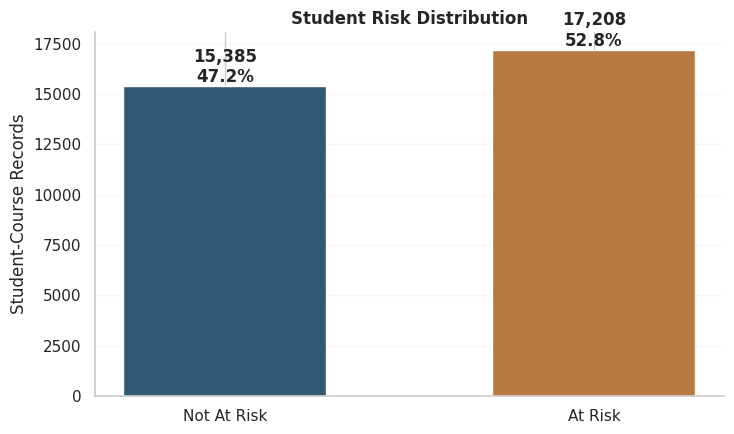

In [ ]:
# Visualize the binary target distribution
target_counts = student_info['risk_label'].value_counts().reindex(['Not At Risk', 'At Risk'])
target_pct = target_counts.div(target_counts.sum()).mul(100)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(target_counts.index, target_counts.values, width=0.55, color=[NOT_RISK_COLOR, RISK_COLOR])
ax.set_title('Student Risk Distribution', fontweight='bold')
ax.set_ylabel('Student-Course Records')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.15)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{count:,}\n{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


The target distribution is reasonably balanced, with **17,208 At Risk records (52.8%)** and **15,385 Not At Risk records (47.2%)**. This means the analysis is not dominated by one class, although Recall, F1, ROC-AUC, and PR-AUC remain important because identifying At-Risk students is the main intervention objective.

## 4. Early Feature Engineering

In [ ]:
# Attach activity type to each VLE interaction
student_vle_typed = student_vle.merge(vle[['code_module', 'code_presentation', 'id_site', 'activity_type']], on=['code_module', 'code_presentation', 'id_site'], how='left')
# Keep the five most-used activity types
TOP_ACTIVITY_TYPES = student_vle_typed.groupby('activity_type')['sum_click'].sum().nlargest(5).index.tolist()
print(TOP_ACTIVITY_TYPES)


['oucontent', 'forumng', 'homepage', 'quiz', 'subpage']


In [ ]:
# Combine assessment metadata with student submissions
assessment_log = assessments.merge(student_assessment, on='id_assessment', how='inner')
print(assessment_log.shape)


(173912, 10)


### 4.1 Engagement Features

In [ ]:
# Build core engagement features within an early cutoff
def build_engagement_features(cutoff_day):
    early_vle = student_vle[(student_vle['date'] >= 0) & (student_vle['date'] <= cutoff_day)].copy()
    engagement = early_vle.groupby(KEY).agg(total_clicks=('sum_click', 'sum'), active_study_days=('date', 'nunique'), materials_touched=('id_site', 'nunique'), last_activity_day=('date', 'max')).reset_index()
    engagement['avg_clicks_per_active_day'] = engagement['total_clicks'] / engagement['active_study_days'].clip(lower=1)
    engagement['days_since_last_activity'] = cutoff_day - engagement['last_activity_day']
    return early_vle, engagement


### 4.2 Inactivity Gap Features

In [ ]:
# Measure gaps between active study days
def build_inactivity_features(early_vle):
    active_dates = early_vle[KEY + ['date']].drop_duplicates().sort_values(KEY + ['date'])
    active_dates['activity_gap'] = active_dates.groupby(KEY)['date'].diff()
    inactivity = active_dates.groupby(KEY).agg(max_inactivity_gap=('activity_gap', 'max'), avg_inactivity_gap=('activity_gap', 'mean')).reset_index()
    return inactivity


`max_inactivity_gap` and `avg_inactivity_gap` capture disengagement patterns that total clicks alone may miss.

### 4.3 Engagement Trend

In [ ]:
# Compare activity in the first and second half of the early window
def build_engagement_trend(early_vle, cutoff_day):
    split_day = cutoff_day // 2
    first_half = early_vle[early_vle['date'] <= split_day].groupby(KEY)['sum_click'].sum().rename('clicks_first_half')
    second_half = early_vle[early_vle['date'] > split_day].groupby(KEY)['sum_click'].sum().rename('clicks_second_half')
    trend = pd.concat([first_half, second_half], axis=1).fillna(0).reset_index()
    trend['engagement_change'] = ((trend['clicks_second_half'] - trend['clicks_first_half']) / (trend['clicks_first_half'] + 1)).clip(-5, 5)
    return trend


### 4.4 Activity-Type Features

In [ ]:
# Create click features for the most common VLE activity types
def build_activity_type_features(cutoff_day):
    early_typed = student_vle_typed[(student_vle_typed['date'] >= 0) & (student_vle_typed['date'] <= cutoff_day)].copy()
    activity_features = early_typed[early_typed['activity_type'].isin(TOP_ACTIVITY_TYPES)].pivot_table(index=KEY, columns='activity_type', values='sum_click', aggfunc='sum', fill_value=0).reset_index()
    activity_features = activity_features.rename(columns={activity: f'clicks_{activity}' for activity in TOP_ACTIVITY_TYPES})
    return activity_features


### 4.5 Assessment and Submission Features

In [ ]:
# Build early academic and submission-behavior features
def build_assessment_features(cutoff_day):
    early_assess = assessment_log[(assessment_log['date_submitted'] >= 0) & (assessment_log['date_submitted'] <= cutoff_day)].copy()
    early_assess['is_late'] = (early_assess['date_submitted'] > early_assess['date']).astype(int)
    early_assess['weighted_score_part'] = early_assess['score'] * early_assess['weight'].fillna(0) / 100
    assessment_features = early_assess.groupby(KEY).agg(avg_score=('score', 'mean'), min_score=('score', 'min'), score_std=('score', 'std'), assessments_completed=('id_assessment', 'count'), avg_submission_day=('date_submitted', 'mean'), late_submission_rate=('is_late', 'mean'), assessment_weight_completed=('weight', 'sum'), weighted_score_earned=('weighted_score_part', 'sum')).reset_index()
    return assessment_features


### 4.6 Build One Early Snapshot

In [ ]:
# Combine all feature groups into one student-course snapshot
def build_snapshot(cutoff_day):
    early_vle, engagement = build_engagement_features(cutoff_day)
    inactivity = build_inactivity_features(early_vle)
    trend = build_engagement_trend(early_vle, cutoff_day)
    activity_types = build_activity_type_features(cutoff_day)
    academic = build_assessment_features(cutoff_day)
    snapshot = student_info.merge(student_reg, on=KEY, how='left')
    for features in [engagement, inactivity, trend, activity_types, academic]:
        snapshot = snapshot.merge(features, on=KEY, how='left')
    snapshot['cutoff_day'] = cutoff_day
    return snapshot


In [ ]:
# Create the main Week-4 snapshot
CUTOFF_DAY = 28
df = build_snapshot(CUTOFF_DAY)
print(df.shape)
display(df.head())


(32593, 41)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,clicks_subpage,avg_score,min_score,score_std,assessments_completed,avg_submission_day,late_submission_rate,assessment_weight_completed,weighted_score_earned,cutoff_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,10.0,78.0,78.0,NaN,1.0,18.0,0.0,10.0,7.8,28
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,36.0,70.0,70.0,NaN,1.0,22.0,1.0,10.0,7.0,28
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,33.0,72.0,72.0,NaN,1.0,17.0,0.0,10.0,7.2,28
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,11.0,69.0,69.0,NaN,1.0,26.0,1.0,10.0,6.9,28


The Week-4 snapshot contains **32,593 student-course records**. This checkpoint is early enough for intervention while providing more behavioral and assessment evidence than the first two weeks.

## 5. Cleaning the Modeling Snapshot

In [ ]:
# Standardize missing text values
missing_text_formats = ['?', 'NA', 'NaN', 'nan', 'null', 'Null', 'NULL', 'None', '', ' ']
df = df.replace(missing_text_formats, np.nan)
df['imd_band'] = df['imd_band'].fillna('Unknown')


In [ ]:
# Fill missing early activity with zero
activity_cols = ['total_clicks', 'active_study_days', 'materials_touched', 'last_activity_day', 'avg_clicks_per_active_day', 'days_since_last_activity', 'max_inactivity_gap', 'avg_inactivity_gap', 'clicks_first_half', 'clicks_second_half', 'engagement_change']
activity_cols += [col for col in df.columns if col.startswith('clicks_')]
for col in activity_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
df['has_vle_activity'] = (df['total_clicks'] > 0).astype(int)


In [ ]:
# Preserve missing assessment information with indicator features
assessment_cols = ['avg_score', 'min_score', 'score_std', 'avg_submission_day', 'late_submission_rate', 'assessment_weight_completed', 'weighted_score_earned']
for col in assessment_cols:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(0)
df['assessments_completed'] = df['assessments_completed'].fillna(0)
df['has_submitted'] = (df['assessments_completed'] > 0).astype(int)


In [ ]:
# Impute registration date within each course presentation
df['date_registration'] = df.groupby(['code_module', 'code_presentation'])['date_registration'].transform(lambda values: values.fillna(values.median()))


In [ ]:
# Convert categorical columns to category dtype
cat_cols = ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
for col in cat_cols:
    df[col] = df[col].astype('category')


In [ ]:
# Remove leakage and identifier columns from the model matrix
df_model = df.drop(columns=['id_student', 'final_result', 'risk_label', 'date_unregistration'])
print('Remaining missing values:', int(df_model.isna().sum().sum()))
print('Modeling shape:', df_model.shape)


Remaining missing values: 0
Modeling shape: (32593, 46)


 After cleaning and feature preparation, the modeling dataset contains **32,593 rows and 46 columns with no remaining missing values**. `date_unregistration` is excluded because it directly reveals withdrawal and would leak the final outcome into the model.

## 6. Exploratory Analysis

### 6.1 Numeric Distribution Check

In [ ]:
# Inspect robust percentiles instead of automatically deleting high values
numeric_check = ['studied_credits', 'num_of_prev_attempts', 'total_clicks', 'active_study_days', 'materials_touched', 'max_inactivity_gap']
distribution_summary = df[numeric_check].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).T
display(distribution_summary[['min', '1%', '25%', '50%', '75%', '95%', '99%', 'max']].round(2))


,min,1%,25%,50%,75%,95%,99%,max
studied_credits,30.0,30.0,60.0,60.0,120.0,150.0,240.00,655.0
num_of_prev_attempts,0.0,0.0,0.0,0.0,0.0,1.0,2.00,6.0
total_clicks,0.0,0.0,30.0,135.0,322.0,818.0,1459.16,6135.0
active_study_days,0.0,0.0,3.0,8.0,15.0,24.0,28.00,29.0
materials_touched,0.0,0.0,7.0,17.0,30.0,56.0,74.00,257.0
max_inactivity_gap,0.0,0.0,2.0,5.0,7.0,13.0,19.00,28.0


### 6.1.1 Outlier Check
Early VLE activity is naturally right-skewed, so extreme values are inspected rather than automatically removed. The boxplots below are used only as a diagnostic check. High engagement can represent genuine study behavior, so valid observations are retained unless there is evidence of a data-quality error.

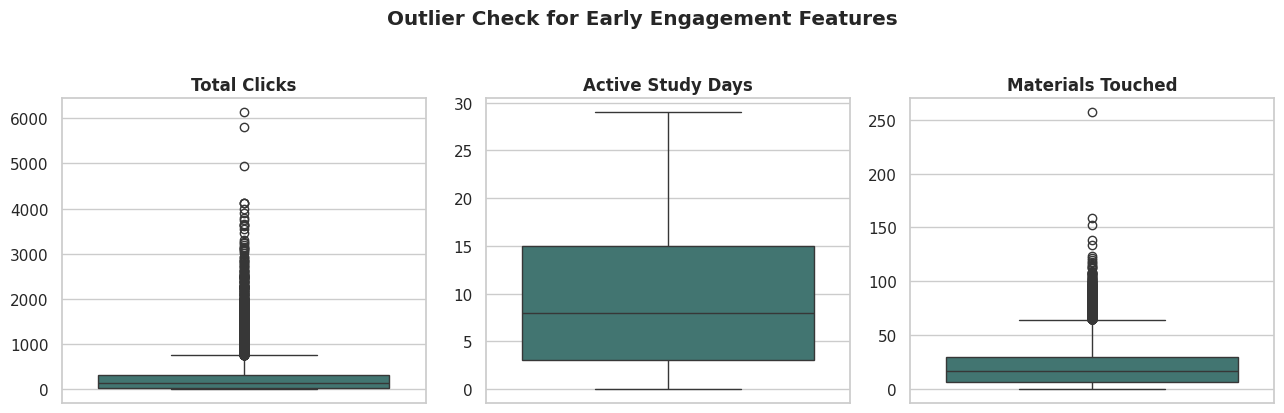

In [ ]:
# Inspect potential outliers in key early engagement variables
outlier_features = ['total_clicks', 'active_study_days', 'materials_touched']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, feature in zip(axes, outlier_features):
    sns.boxplot(y=df[feature], ax=ax, color=ACCENT_COLOR)
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle('Outlier Check for Early Engagement Features', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


The boxplots show that **total clicks** and **materials touched** contain a noticeable upper tail, while **active study days** is much less affected by extreme values. The IQR check identifies these as potential outliers rather than automatic errors, so high-engagement records are retained because they may represent genuine student behavior.

In [ ]:
# Quantify potential IQR outliers without deleting valid high-engagement records
outlier_rows = []
for feature in outlier_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[feature] < lower) | (df[feature] > upper)).sum()
    outlier_rows.append({'Feature': feature, 'Lower Bound': lower, 'Upper Bound': upper, 'Potential Outliers': count, 'Percentage': count / len(df) * 100})
outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.round(2))


,Feature,Lower Bound,Upper Bound,Potential Outliers,Percentage
0,total_clicks,-408.0,760.0,1920,5.89
1,active_study_days,-15.0,33.0,0,0.00
2,materials_touched,-27.5,64.5,745,2.29


The IQR check flags **5.89%** of `total_clicks` and **2.29%** of `materials_touched` as potential outliers, while `active_study_days` has no IQR outliers. These observations are retained because unusually high engagement can be genuine student behavior rather than a data-quality error.

### 6.2 Demographic Risk Patterns

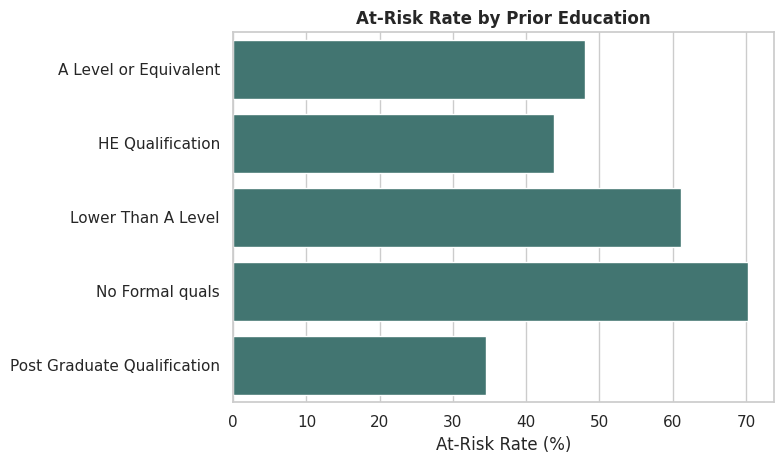

In [ ]:
# Calculate At-Risk rate by prior education
education_risk = df.groupby('highest_education', observed=True)['target'].mean().mul(100).sort_values().reset_index(name='At-Risk Rate')
plt.figure(figsize=(8, 4.8))
sns.barplot(data=education_risk, y='highest_education', x='At-Risk Rate', color=ACCENT_COLOR)
plt.title('At-Risk Rate by Prior Education', fontweight='bold')
plt.xlabel('At-Risk Rate (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()


At-Risk rates vary across prior-education groups, suggesting that students enter the course with different levels of observed risk. This pattern is useful for identifying groups that may benefit from additional support, but prior education is treated as contextual information rather than a stand-alone reason to flag an individual student.

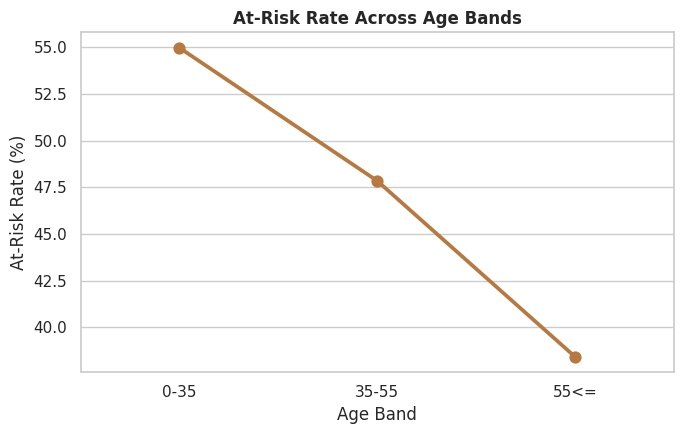

In [ ]:
# Calculate At-Risk rate by age band
age_risk = df.groupby('age_band', observed=True)['target'].mean().mul(100).reset_index(name='At-Risk Rate')
plt.figure(figsize=(7, 4.5))
sns.pointplot(data=age_risk, x='age_band', y='At-Risk Rate', color=RISK_COLOR, markers='o')
plt.title('At-Risk Rate Across Age Bands', fontweight='bold')
plt.xlabel('Age Band')
plt.ylabel('At-Risk Rate (%)')
plt.tight_layout()
plt.show()


The At-Risk rate differs across age bands, showing that final outcomes are not distributed equally across age groups in this dataset. This is interpreted as a descriptive group-level pattern only; age itself should not be treated as a causal explanation or used alone to make an intervention decision.

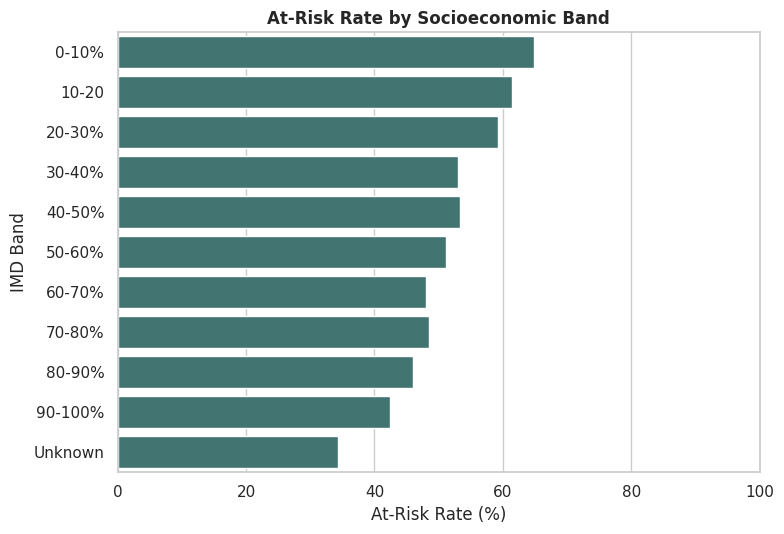

In [ ]:
# Compare At-Risk rate across socioeconomic groups
imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', 'Unknown']
imd_risk = df.groupby('imd_band', observed=True)['target'].agg(['mean', 'count']).reset_index()
imd_risk['At-Risk Rate'] = imd_risk['mean'] * 100
imd_risk['imd_band'] = pd.Categorical(imd_risk['imd_band'], categories=imd_order, ordered=True)
imd_risk = imd_risk.sort_values('imd_band')
plt.figure(figsize=(8, 5.5))
sns.barplot(data=imd_risk, y='imd_band', x='At-Risk Rate', color=ACCENT_COLOR)
plt.title('At-Risk Rate by Socioeconomic Band', fontweight='bold')
plt.xlabel('At-Risk Rate (%)')
plt.ylabel('IMD Band')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


At-Risk rates also vary across socioeconomic (IMD) bands, indicating a group-level relationship between socioeconomic context and student outcomes. The **Unknown** category represents missing IMD information and is not interpreted as a socioeconomic group, while the observed differences are used for equity monitoring rather than individual decision-making.

Demographic patterns are interpreted as associations for equity monitoring, not as causal explanations or stand-alone reasons for intervention.

### 6.3 Engagement and Risk

In [ ]:
# Compare median early behavior between the two risk groups
behavior_summary = df.groupby('risk_label')[['total_clicks', 'active_study_days', 'materials_touched', 'days_since_last_activity', 'max_inactivity_gap', 'avg_score']].median().T
display(behavior_summary.round(2))


risk_label,At Risk,Not At Risk
total_clicks,64.5,227.0
active_study_days,5.0,12.0
materials_touched,11.0,22.0
days_since_last_activity,1.0,1.0
max_inactivity_gap,4.0,5.0
avg_score,0.0,76.0


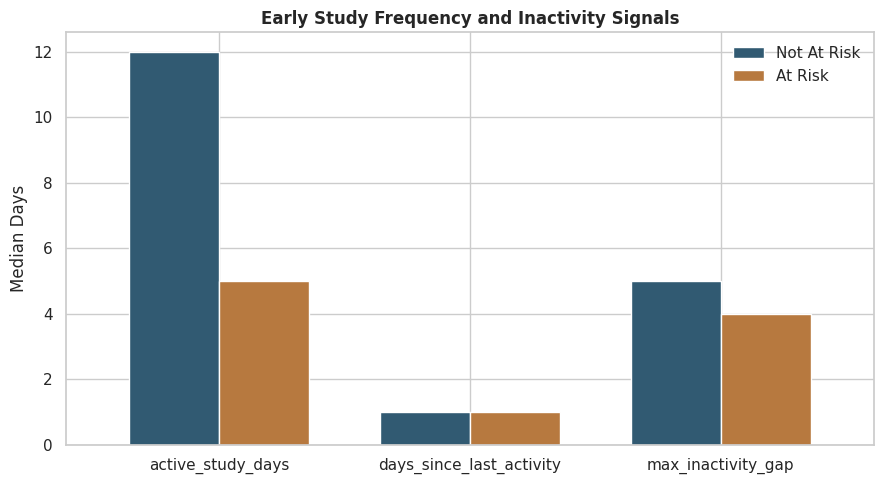

In [ ]:
# Compare early study frequency between risk groups
study_frequency = df.groupby('risk_label')[['active_study_days', 'days_since_last_activity', 'max_inactivity_gap']].median().reindex(['Not At Risk', 'At Risk'])
study_frequency.T.plot(kind='bar', figsize=(9, 5), color=[NOT_RISK_COLOR, RISK_COLOR], width=0.72)
plt.title('Early Study Frequency and Inactivity Signals', fontweight='bold')
plt.xlabel('')
plt.ylabel('Median Days')
plt.xticks(rotation=0)
plt.legend(title='', frameon=False)
plt.tight_layout()
plt.show()


By Week 4, the median At-Risk student has only **5 active study days**, compared with **12 days** for Not At Risk students, showing a clear difference in early study frequency. In contrast, days since last activity is similar across both groups, while the median maximum inactivity gap is slightly lower for At-Risk students (**4 vs 5 days**). This suggests that overall study frequency is a clearer early risk signal than inactivity gaps alone.

### 6.4 VLE Activity Types

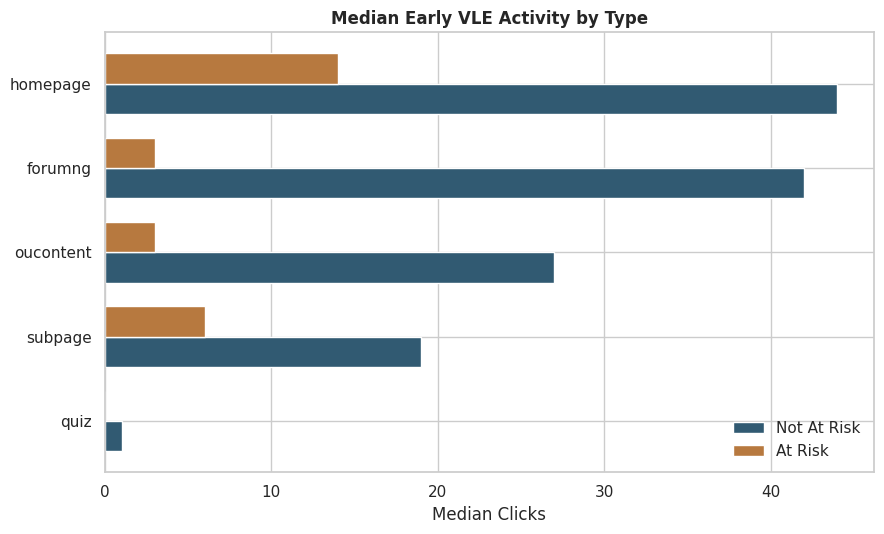

In [ ]:
# Compare median clicks across the most common VLE activity types
type_cols = [f'clicks_{activity}' for activity in TOP_ACTIVITY_TYPES]
type_summary = df.groupby('risk_label')[type_cols].median().T
type_summary.index = type_summary.index.str.replace('clicks_', '', regex=False)
type_summary = type_summary[['Not At Risk', 'At Risk']]
ax = type_summary.sort_values('Not At Risk').plot(kind='barh', figsize=(9, 5.5), color=[NOT_RISK_COLOR, RISK_COLOR], width=0.72)
ax.set_title('Median Early VLE Activity by Type', fontweight='bold')
ax.set_xlabel('Median Clicks')
ax.set_ylabel('')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


The VLE activity-type comparison shows that the engagement gap is not limited to total click volume; the two risk groups also interact differently across specific course resources. Not At Risk students generally show higher median interaction with the main VLE activity types, suggesting broader early participation across learning resources rather than activity concentrated in only one area.

### 6.5 Early Assessment Signal

In [ ]:
# Compare early assessment participation between risk groups
assessment_participation = df.groupby('risk_label')[['assessments_completed', 'assessment_weight_completed', 'late_submission_rate']].median().T
assessment_participation = assessment_participation[['Not At Risk', 'At Risk']]
display(assessment_participation.round(2))


risk_label,Not At Risk,At Risk
assessments_completed,1.0,0.0
assessment_weight_completed,5.0,0.0
late_submission_rate,0.0,0.0


Assessment participation itself is an early signal: the median Not At Risk student has completed **1 assessment** and **5% assessment weight** by Week 4, while the median At-Risk student has not yet completed an assessment.

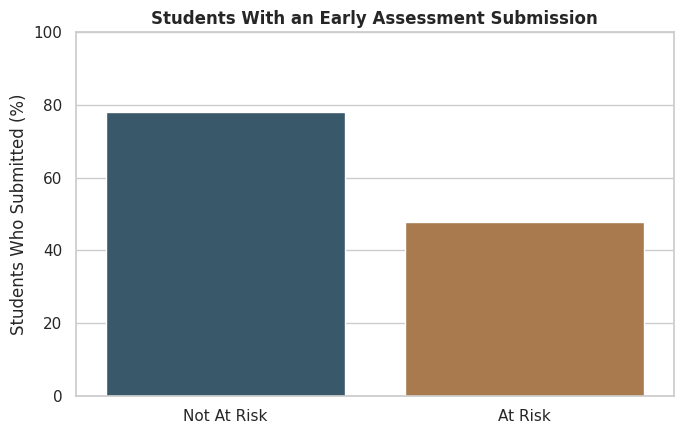

In [ ]:
# Compare the share of students who submitted at least one early assessment
submission_rate = df.groupby('risk_label')['has_submitted'].mean().mul(100).reindex(['Not At Risk', 'At Risk']).reset_index(name='Submitted')
plt.figure(figsize=(7, 4.5))
sns.barplot(data=submission_rate, x='risk_label', y='Submitted', hue='risk_label', palette=[NOT_RISK_COLOR, RISK_COLOR], legend=False)
plt.title('Students With an Early Assessment Submission', fontweight='bold')
plt.xlabel('')
plt.ylabel('Students Who Submitted (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


A larger share of Not At Risk students complete at least one assessment during the early period, while early non-submission is more common among At-Risk students. This makes **assessment participation itself an early warning signal**, and it is kept separate from score so that a missing submission is not incorrectly interpreted as a score of zero.

### 6.6 Scores Among Students Who Submitted


,median,mean,count
risk_label,,,
Not At Risk,80.0,77.53,12016
At Risk,70.0,65.80,8229


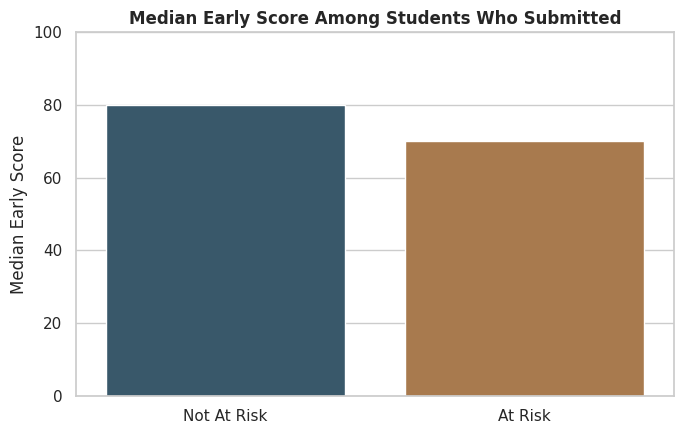

In [ ]:
# Compare scores only among students with at least one submitted assessment
submitted_only = df[df['has_submitted'] == 1].copy()
score_by_risk = submitted_only.groupby('risk_label')['avg_score'].agg(['median', 'mean', 'count']).reindex(['Not At Risk', 'At Risk'])
display(score_by_risk.round(2))
plt.figure(figsize=(7, 4.5))
sns.barplot(data=submitted_only, x='risk_label', y='avg_score', estimator=np.median, errorbar=None, order=['Not At Risk', 'At Risk'], palette=[NOT_RISK_COLOR, RISK_COLOR], hue='risk_label', legend=False)
plt.title('Median Early Score Among Students Who Submitted', fontweight='bold')
plt.xlabel('')
plt.ylabel('Median Early Score')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


Among students who actually submitted an early assessment, the median score is **80 for Not At Risk** compared with **70 for At Risk** students. The mean scores show the same pattern (**77.53 vs 65.80**), confirming that early assessment performance remains informative even after separating non-submission from low scores.

Assessment performance is considered together with engagement because one signal alone may not fully represent student risk.

## 7. How Early Can Risk Be Detected?

In [ ]:
# Define the early checkpoints
CHECKPOINTS = {'Week 2': 14, 'Week 4': 28, 'Week 6': 42, 'Week 8': 56}


In [ ]:
# Prepare one checkpoint dataset for modeling
def prepare_checkpoint(cutoff_day):
    snapshot = build_snapshot(cutoff_day)
    snapshot['imd_band'] = snapshot['imd_band'].fillna('Unknown')
    snapshot['target'] = snapshot['final_result'].isin(['Fail', 'Withdrawn']).astype(int)
    groups = snapshot['id_student']
    X = snapshot.drop(columns=['id_student', 'final_result', 'risk_label', 'date_unregistration', 'target', 'cutoff_day'])
    y = snapshot['target']
    return X, y, groups


In [ ]:
# Evaluate Logistic Regression at one checkpoint
def evaluate_checkpoint(cutoff_day):
    Xc, yc, groups = prepare_checkpoint(cutoff_day)
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(Xc, yc, groups=groups))
    X_train_c = Xc.iloc[train_idx]
    X_test_c = Xc.iloc[test_idx]
    y_train_c = yc.iloc[train_idx]
    y_test_c = yc.iloc[test_idx]
    numeric_cols = X_train_c.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X_train_c.select_dtypes(exclude=np.number).columns.tolist()
    preprocessor_c = ColumnTransformer([('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols), ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)])
    model = Pipeline([('preprocessor', preprocessor_c), ('classifier', LogisticRegression(class_weight='balanced', max_iter=1500, random_state=42))])
    model.fit(X_train_c, y_train_c)
    probability = model.predict_proba(X_test_c)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    return average_precision_score(y_test_c, probability), recall_score(y_test_c, prediction), f1_score(y_test_c, prediction)


In [ ]:
# Compare Week 2, Week 4, Week 6, and Week 8
checkpoint_rows = []
for label, day in CHECKPOINTS.items():
    pr_auc, recall, f1 = evaluate_checkpoint(day)
    checkpoint_rows.append({'Checkpoint': label, 'Day': day, 'PR-AUC': pr_auc, 'At-Risk Recall': recall, 'At-Risk F1': f1})
cutoff_results = pd.DataFrame(checkpoint_rows)
display(cutoff_results.round(3))


,Checkpoint,Day,PR-AUC,At-Risk Recall,At-Risk F1
0,Week 2,14,0.813,0.711,0.729
1,Week 4,28,0.861,0.716,0.752
2,Week 6,42,0.874,0.734,0.769
3,Week 8,56,0.878,0.762,0.787


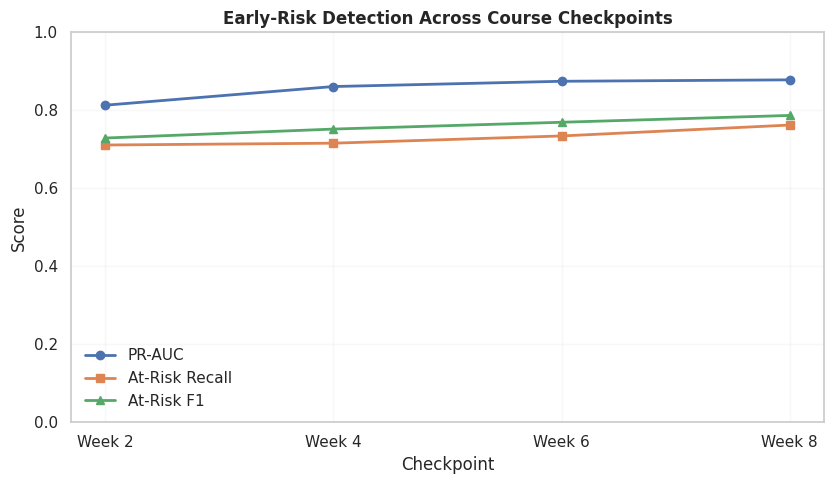

In [ ]:
# Visualize performance across early checkpoints
plt.figure(figsize=(8.5, 5))
for metric, marker in [('PR-AUC', 'o'), ('At-Risk Recall', 's'), ('At-Risk F1', '^')]:
    plt.plot(cutoff_results['Day'], cutoff_results[metric], marker=marker, linewidth=2, label=metric)
plt.title('Early-Risk Detection Across Course Checkpoints', fontweight='bold')
plt.xlabel('Checkpoint')
plt.ylabel('Score')
plt.xticks(cutoff_results['Day'], cutoff_results['Checkpoint'])
plt.ylim(0, 1)
plt.grid(alpha=0.15)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


Predictive performance improves as more course information becomes available: PR-AUC increases from **0.813 in Week 2** to **0.861 in Week 4**, **0.874 in Week 6**, and **0.878 in Week 8**. Although later checkpoints perform slightly better, Week 4 provides a practical balance because it captures a substantial improvement over Week 2 while still leaving enough time for early intervention.

## 8. Baseline and Ensemble Modeling

### 8.1 Group-Aware Train/Test Split

In [ ]:
# Keep each student entirely in train or test
groups = df['id_student']
X = df_model.drop(columns=['target'])
y = df_model['target']
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
print('Train:', X_train.shape)
print('Test:', X_test.shape)


Train: (26122, 45)
Test: (6471, 45)


 The group-aware split produces **26,122 training records** and **6,471 test records** while keeping each student in only one side of the split. This gives a more realistic estimate of generalization to unseen students.

A group-aware split prevents the same student from appearing in both training and testing when they have more than one course record.

### 8.2 Preprocessing

In [ ]:
# Build the preprocessing pipeline
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols_model = X_train.select_dtypes(exclude=np.number).columns.tolist()
preprocessor = ColumnTransformer([('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols), ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_cols_model)])


### 8.3 Logistic Regression Baseline

In [ ]:
# Train the simple baseline
logistic_model = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(class_weight='balanced', max_iter=1500, random_state=42))])
logistic_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_of_prev_attempts',
                                                   'studied_credits',
                                                   'date_registration',
                                                   'total_clicks',
                                                   'active_study_days',
                                                   'materials_touched',
                                                   'last_activity_day',
                                                   'avg_clicks_per_active_day',
                                                   'days_since_last_activi...
                                                   'avg_score_missing', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['code_module',
                                                   'code_presentation',
                                                   'gender', 'region',
                                                   'highest_education',
                                                   'imd_band', 'age_band',
                                                   'disability'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1500,
                                    random_state=42))])

### 8.4 Random Forest

In [ ]:
# Train a bagging ensemble
random_forest_model = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=350, class_weight='balanced', min_samples_leaf=2, random_state=42, n_jobs=-1))])
random_forest_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_of_prev_attempts',
                                                   'studied_credits',
                                                   'date_registration',
                                                   'total_clicks',
                                                   'active_study_days',
                                                   'materials_touched',
                                                   'last_activity_day',
                                                   'avg_clicks_per_active_day',
                                                   'days_since_last_activi...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['code_module',
                                                   'code_presentation',
                                                   'gender', 'region',
                                                   'highest_education',
                                                   'imd_band', 'age_band',
                                                   'disability'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=350,
                                        n_jobs=-1, random_state=42))])

### 8.5 XGBoost

In [ ]:
# Train a boosting ensemble
xgboost_model = Pipeline([('preprocessor', preprocessor), ('classifier', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, eval_metric='logloss', random_state=42, n_jobs=-1))])
xgboost_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_of_prev_attempts',
                                                   'studied_credits',
                                                   'date_registration',
                                                   'total_clicks',
                                                   'active_study_days',
                                                   'materials_touched',
                                                   'last_activity_day',
                                                   'avg_clicks_per_active_day',
                                                   'days_since_last_activi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### 8.6 Model Comparison

In [ ]:
# Evaluate all models using imbalance-aware metrics
fitted_models = {'Logistic Regression': logistic_model, 'Random Forest': random_forest_model, 'XGBoost': xgboost_model}
model_rows = []
for name, model in fitted_models.items():
    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    model_rows.append({'Model': name, 'PR-AUC': average_precision_score(y_test, probability), 'ROC-AUC': roc_auc_score(y_test, probability), 'Precision': precision_score(y_test, prediction), 'Recall': recall_score(y_test, prediction), 'F1': f1_score(y_test, prediction)})
model_results = pd.DataFrame(model_rows).sort_values('PR-AUC', ascending=False)
display(model_results.round(4))


,Model,PR-AUC,ROC-AUC,Precision,Recall,F1
2,XGBoost,0.8807,0.8470,0.8005,0.7345,0.7661
1,Random Forest,0.8758,0.8410,0.8090,0.7119,0.7574
0,Logistic Regression,0.8719,0.8388,0.8129,0.7069,0.7562


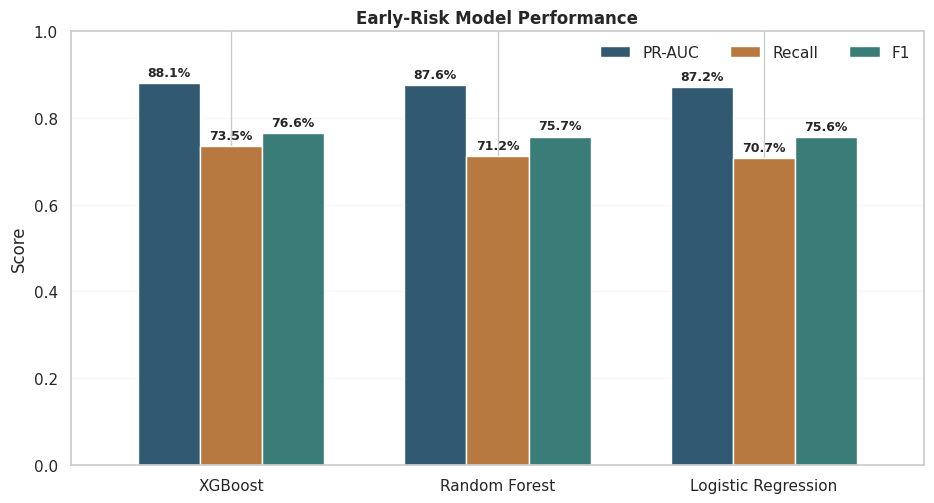

In [ ]:
# Visualize the most relevant model metrics
plot_df = model_results.set_index('Model')[['PR-AUC', 'Recall', 'F1']]
ax = plot_df.plot(
    kind='bar',
    figsize=(9.5, 5.2),
    width=0.70,
    color=[NOT_RISK_COLOR, RISK_COLOR, ACCENT_COLOR]
)
ax.set_title('Early-Risk Model Performance', fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.15)

# Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value * 100:.1f}%' for value in container.datavalues],
        padding=3,
        fontsize=9,
        fontweight='bold'
    )

plt.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

XGBoost provides the strongest overall balance among the tested models, achieving **PR-AUC = 0.8807**, **Recall = 0.7345**, and **F1 = 0.7661**. Random Forest and Logistic Regression remain competitive, but XGBoost's stronger PR-AUC and At-Risk Recall make it the preferred model for further tuning and threshold optimization.

## 9. XGBoost Optimization

### 9.1 Focused Hyperparameter Search

In [ ]:
# Define a focused XGBoost search space
xgb_tuning_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1))])
param_dist = {'classifier__n_estimators': [200, 300, 450, 600], 'classifier__max_depth': [2, 3, 4, 5], 'classifier__learning_rate': [0.02, 0.04, 0.06, 0.10], 'classifier__subsample': [0.75, 0.85, 1.0], 'classifier__colsample_bytree': [0.70, 0.85, 1.0], 'classifier__min_child_weight': [1, 3, 5], 'classifier__reg_alpha': [0, 0.05, 0.20], 'classifier__reg_lambda': [1, 2, 5]}


In [ ]:
# Tune XGBoost with student-level grouped cross-validation
groups_train = groups.iloc[train_idx].reset_index(drop=True)
group_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(xgb_tuning_pipeline, param_distributions=param_dist, n_iter=15, scoring='average_precision', cv=group_cv, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train, groups=groups_train)
print('Best grouped CV PR-AUC:', round(search.best_score_, 4))
print(search.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best grouped CV PR-AUC: 0.8782
{'classifier__subsample': 0.85, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.04, 'classifier__colsample_bytree': 0.85}


 Grouped cross-validation gives a best PR-AUC of **0.8782**, close to the held-out performance. This consistency suggests that the model is not relying on student overlap between folds.

### 9.2 Group-Aware Validation and Threshold Selection
The threshold is selected on a student-level validation set. Because the purpose of the system is early intervention, the selection first requires **At-Risk Recall of at least 80%**, then chooses the threshold with the strongest precision among the eligible options. This reduces unnecessary alerts while keeping the main intervention objective.

In [ ]:
# Create a student-level validation split from the training set
validation_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=21)
fit_idx, val_idx = next(validation_splitter.split(X_train, y_train, groups=groups_train))
X_fit = X_train.iloc[fit_idx]
X_val = X_train.iloc[val_idx]
y_fit = y_train.iloc[fit_idx]
y_val = y_train.iloc[val_idx]
validation_model = search.best_estimator_
validation_model.fit(X_fit, y_fit)
val_probability = validation_model.predict_proba(X_val)[:, 1]
print('Unique students in both fit and validation:', len(set(groups_train.iloc[fit_idx]).intersection(set(groups_train.iloc[val_idx]))))


Unique students in both fit and validation: 0


 The overlap check returns **0 shared students** between the fitting and validation subsets, confirming that threshold selection is also student-level and leakage-aware.

In [ ]:
# Compare probability thresholds using the validation set
thresholds = np.arange(0.30, 0.71, 0.02)
threshold_table = pd.DataFrame({'Threshold': thresholds, 'Precision': [precision_score(y_val, (val_probability >= threshold).astype(int)) for threshold in thresholds], 'Recall': [recall_score(y_val, (val_probability >= threshold).astype(int)) for threshold in thresholds], 'F1': [f1_score(y_val, (val_probability >= threshold).astype(int)) for threshold in thresholds], 'Accuracy': [((val_probability >= threshold).astype(int) == y_val.to_numpy()).mean() for threshold in thresholds]})
eligible_thresholds = threshold_table[threshold_table['Recall'] >= 0.80].copy()
if len(eligible_thresholds) > 0:
    best_threshold = eligible_thresholds.sort_values(['Precision', 'F1'], ascending=False).iloc[0]['Threshold']
else:
    best_threshold = threshold_table.loc[threshold_table['F1'].idxmax(), 'Threshold']
print('Selected threshold:', round(float(best_threshold), 2))
display(threshold_table.sort_values('Threshold').round(4))


Selected threshold: 0.4


,Threshold,Precision,Recall,F1,Accuracy
0,0.30,0.6746,0.9053,0.7731,0.7193
1,0.32,0.6911,0.8847,0.7760,0.7302
2,0.34,0.7061,0.8700,0.7795,0.7401
3,0.36,0.7212,0.8527,0.7814,0.7480
4,0.38,0.7385,0.8372,0.7847,0.7574
5,0.40,0.7527,0.8181,0.7840,0.7619
6,0.42,0.7648,0.7965,0.7803,0.7631
7,0.44,0.7799,0.7810,0.7804,0.7678
8,0.46,0.7897,0.7586,0.7738,0.7657
9,0.48,0.8061,0.7428,0.7732,0.7697


A threshold of **0.40** is selected. On validation data it keeps At-Risk Recall above the 80% target (**0.818**) while improving Precision to **0.753**. Higher thresholds improve Accuracy slightly but fall below the intervention Recall target.

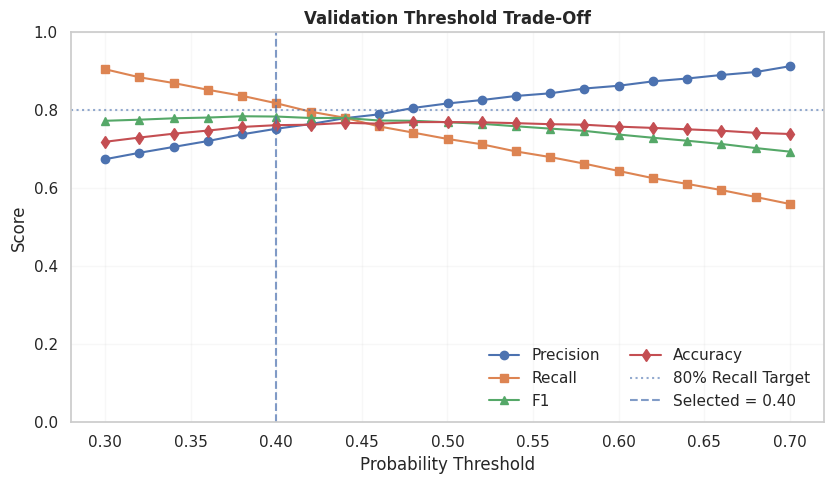

In [ ]:
# Visualize the operational threshold trade-off
plt.figure(figsize=(8.5, 5))
plt.plot(threshold_table['Threshold'], threshold_table['Precision'], marker='o', label='Precision')
plt.plot(threshold_table['Threshold'], threshold_table['Recall'], marker='s', label='Recall')
plt.plot(threshold_table['Threshold'], threshold_table['F1'], marker='^', label='F1')
plt.plot(threshold_table['Threshold'], threshold_table['Accuracy'], marker='d', label='Accuracy')
plt.axhline(0.80, linestyle=':', alpha=0.6, label='80% Recall Target')
plt.axvline(best_threshold, linestyle='--', alpha=0.7, label=f'Selected = {best_threshold:.2f}')
plt.title('Validation Threshold Trade-Off', fontweight='bold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(alpha=0.15)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


The threshold curve shows the operational trade-off between catching more At-Risk students and generating additional alerts. Lower thresholds increase Recall but reduce Precision, while higher thresholds do the opposite. A threshold of **0.40** is selected because it keeps validation At-Risk Recall above the predefined **80% target** while preserving the strongest available Precision among eligible thresholds.

### 9.3 Final Test Evaluation

In [ ]:
# Refit the tuned model on all training data
ensemble = search.best_estimator_
ensemble.fit(X_train, y_train)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]
y_pred_ens = (y_prob_ens >= best_threshold).astype(int)
print('Final PR-AUC:', round(average_precision_score(y_test, y_prob_ens), 4))
print('Final ROC-AUC:', round(roc_auc_score(y_test, y_prob_ens), 4))
print(classification_report(y_test, y_pred_ens, target_names=['Not At Risk', 'At Risk']))


Final PR-AUC: 0.8806
Final ROC-AUC: 0.8469
              precision    recall  f1-score   support

 Not At Risk       0.77      0.67      0.72      3073
     At Risk       0.74      0.82      0.77      3398

    accuracy                           0.75      6471
   macro avg       0.75      0.75      0.75      6471
weighted avg       0.75      0.75      0.75      6471



On the untouched test set, the final model achieves **PR-AUC 0.8806**, **ROC-AUC 0.8469**, and **75% Accuracy**. Most importantly for the intervention goal, At-Risk Recall is **0.82** with F1 **0.77**.

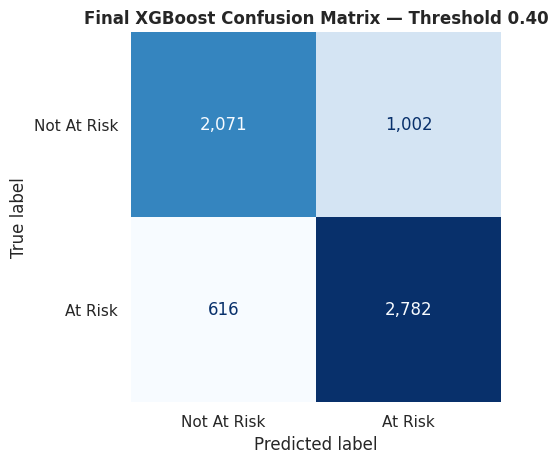

In [ ]:
# Plot the final confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ens,
    display_labels=['Not At Risk', 'At Risk'],
    cmap='Blues',
    colorbar=False,
    values_format=',d'
)

# Remove grid lines
ax = disp.ax_
ax.grid(False)

# Remove outer borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title(
    f'Final XGBoost Confusion Matrix — Threshold {best_threshold:.2f}',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

At the selected **0.40 threshold**, the model correctly identifies **2,782 of 3,398 At-Risk records** and misses **616**, corresponding to an At-Risk Recall of about **82%**. It also flags **1,002 Not At Risk records** as At Risk while correctly classifying **2,071** as Not At Risk. This reflects the intervention strategy: accepting more false-positive alerts in order to miss fewer students who may genuinely need support.

### 9.4 Precision-Recall Curve

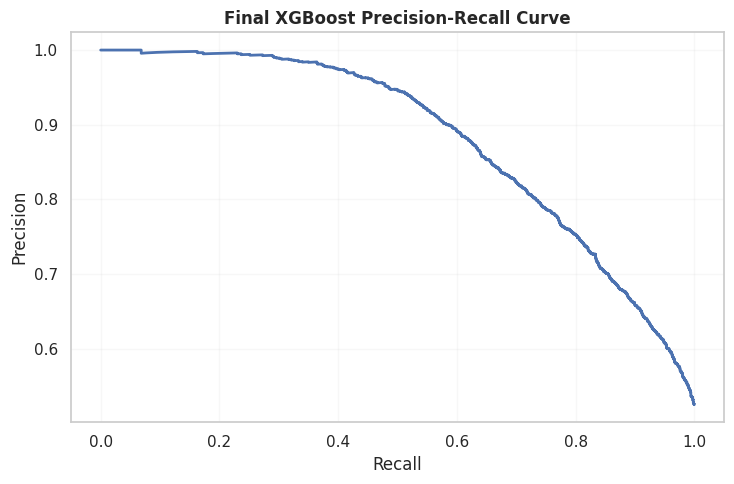

In [ ]:
# Plot the final precision-recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_ens)
plt.figure(figsize=(7.5, 5))
plt.plot(recall_curve, precision_curve, linewidth=2)
plt.title('Final XGBoost Precision-Recall Curve', fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()


The Precision-Recall curve evaluates the model across all possible classification thresholds rather than only the selected 0.40 operating point. The final **PR-AUC of 0.8806** indicates strong precision-recall performance for the At-Risk class, while the chosen threshold determines the specific Recall-versus-Precision trade-off used for intervention.

## 10. Interpretability

### 10.1 Prepare SHAP Values

In [ ]:
# Transform the test data using the final preprocessing pipeline
X_test_transformed = ensemble.named_steps['preprocessor'].transform(X_test)
X_test_shap = X_test_transformed.toarray() if hasattr(X_test_transformed, 'toarray') else X_test_transformed
categorical_feature_names = ensemble.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols_model).tolist()
feature_names = num_cols + categorical_feature_names
explainer = shap.TreeExplainer(ensemble.named_steps['classifier'])
shap_values = explainer(X_test_shap)
shap_values.feature_names = feature_names


### 10.2 Global Interpretability

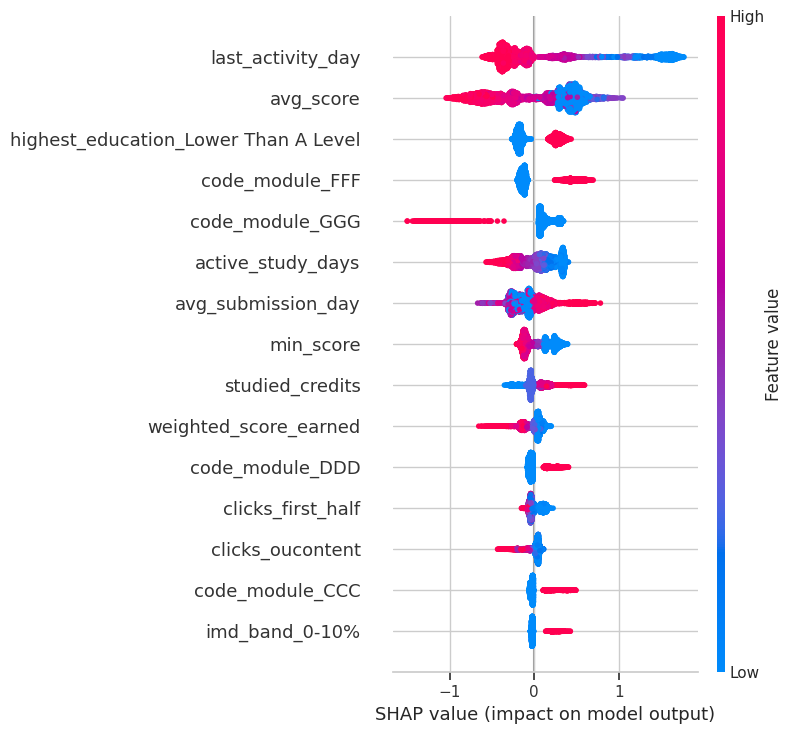

In [ ]:
# Show the most influential features across the test set
shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, max_display=15)


The global SHAP summary shows that the model does not rely on a single variable. Predictions are influenced by a combination of **activity timing, early assessment performance, study frequency, submission behavior, course context, and prior education**, with `last_activity_day` and `avg_score` among the strongest global contributors. This supports combining behavioral and academic signals for early-risk detection.

### 10.3 Individual Student Explanation

In [ ]:
# Select a correctly identified At-Risk student with a representative probability
correct_at_risk = np.where((y_test.reset_index(drop=True).values == 1) & (y_pred_ens == 1))[0]
median_probability = np.median(y_prob_ens[correct_at_risk])
student_idx = correct_at_risk[np.argmin(np.abs(y_prob_ens[correct_at_risk] - median_probability))]
print('Selected At-Risk probability:', round(y_prob_ens[student_idx], 3))
display(X_test.iloc[[student_idx]])


Selected At-Risk probability: 0.85


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,cutoff_day,has_vle_activity,avg_score_missing,min_score_missing,score_std_missing,avg_submission_day_missing,late_submission_rate_missing,assessment_weight_completed_missing,weighted_score_earned_missing,has_submitted
18614,DDD,2014J,M,Yorkshire Region,A Level or Equivalent,10-20,35-55,0,120,N,...,28,1,0,0,1,0,0,0,0,1


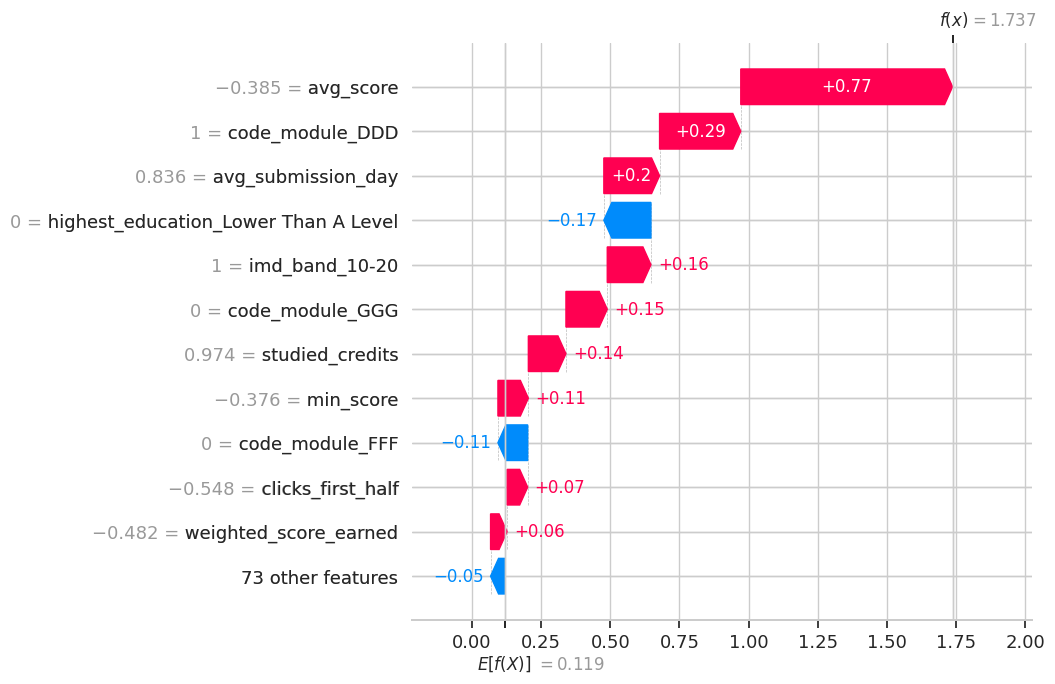

In [ ]:
# Explain why this student was flagged
shap.plots.waterfall(shap_values[student_idx], max_display=12)


This correctly identified At-Risk case has a predicted risk probability of approximately **0.85**. The SHAP waterfall explains how individual features move this prediction toward or away from the At-Risk class, with early assessment and submission-related information contributing to the final decision. For an advisor, the most useful response is to focus on actionable academic and engagement signals rather than demographic characteristics.

## 11. Key Insights and Recommendations

- **Week 4 is a useful intervention point:** PR-AUC reaches **0.861**, compared with **0.813 in Week 2**, while still leaving enough time for early support.

- **Early engagement is an important risk signal:** At-Risk students show substantially fewer active study days, fewer clicks, and fewer learning materials accessed during the first four weeks.

- **Assessment participation and performance provide different signals:** At-Risk students are more likely to have no early submission, and even among students who submit, their early scores remain lower.

- **XGBoost provides the strongest overall performance:** it achieves the highest PR-AUC, ROC-AUC, Recall, and F1 among the tested models, while grouped cross-validation remains consistent at **0.8782 PR-AUC**.

- **The 0.40 threshold supports the intervention objective:** the final model reaches **0.82 At-Risk Recall**, prioritizing the identification of students who may need support rather than maximizing Accuracy alone.

- **Predictions should be accompanied by explanations:** SHAP can show advisors which behavioral and academic factors contributed to an individual student's risk prediction.

- **Interventions should focus on actionable signals:** low engagement, limited study activity, non-submission, late submission, and weak early assessment performance can guide targeted support.

- **Demographic information should be used carefully:** group-level patterns can support equity monitoring, but demographic characteristics should not be used as the sole basis for individual intervention decisions.

## 12. Conclusion

This case study demonstrates that meaningful student-risk detection is possible within the **first four weeks of a course** by combining early engagement, assessment behavior, and student information.

### Main Conclusions

- **Early risk detection is feasible:** Week 4 achieved a **PR-AUC of 0.861**, providing a strong balance between predictive performance and enough time for intervention.

- **Behavioral and academic signals work best together:** At-Risk students showed lower early engagement and weaker assessment participation and performance, indicating that risk should not be determined from a single feature.

- **XGBoost provided the strongest overall performance:** the final model achieved **PR-AUC = 0.8806**, **ROC-AUC = 0.8469**, and **At-Risk F1 = 0.77**.

- **The final system prioritizes intervention:** using a threshold of **0.40**, the model identified approximately **82% of At-Risk students**, while SHAP provided explanations to help advisors understand and act on individual predictions.

### Final Takeaway

The main value of the proposed system is not simply achieving the highest possible Accuracy. Its value comes from combining:

**Early detection + strong At-Risk Recall + explainable predictions + actionable intervention signals.**

The model should therefore be used as a **decision-support tool** to help advisors identify students who may need attention, understand why they were flagged, and provide timely support.

---

## Limitations

- **Single educational context:** OULAD represents one online-learning environment. Student behavior, course structure, and assessment patterns may differ across institutions, so the model should be externally validated before deployment elsewhere.

- **Historical data:** OULAD represents an earlier online-learning environment and may not fully capture current learning behavior across mobile applications, video platforms, live sessions, and other modern learning tools.

- **VLE activity is only a proxy for engagement:** a high number of clicks does not necessarily indicate effective learning, while a student with fewer clicks may still be studying successfully through other resources.

- **Assessment availability is approximated:** OULAD provides submission timing but does not provide the exact time at which each assessment grade became available to the student or advisor. The early-warning analysis therefore assumes that scores submitted within the cutoff are available at that checkpoint.

- **The intervention threshold introduces a trade-off:** the selected **0.40 threshold** improves At-Risk Recall to approximately **82%**, but it also produces more false-positive alerts. In the final test set, **1,002 Not At Risk records were flagged as At Risk**, while **616 At-Risk records were still missed**.

- **Risk changes over time:** Week 8 produced stronger predictive performance than Week 4, but waiting longer reduces the opportunity for early intervention. Week 4 should therefore be viewed as a practical balance between prediction quality and intervention time rather than a universally optimal cutoff.

Demographic associations should also be interpreted carefully. Differences across demographic or socioeconomic groups represent **associations rather than causal relationships** and should be used for fairness monitoring and support planning, not as the sole basis for individual decisions.

---

## Future Work

Future improvements could extend the current analysis in several directions:

- **Dynamic risk monitoring:** instead of generating only one Week-4 prediction, risk probabilities could be updated regularly as new engagement and assessment information becomes available.

- **External validation:** the model should be evaluated on data from other courses, institutions, or more recent online-learning environments to test its generalizability.

- **Richer behavioral features:** additional information such as recent activity trends, changes in engagement, assessment progression, and other learning-platform interactions could improve early detection.

- **Advisor-capacity-aware thresholding:** the operating threshold could be adjusted according to the number of students that advisors are realistically able to contact and support.

- **Fairness evaluation:** model performance could be monitored across demographic and socioeconomic groups to identify whether prediction errors disproportionately affect particular student groups.

- **Intervention effectiveness:** future work should evaluate not only whether the model predicts risk correctly, but also whether interventions triggered by the model actually improve student outcomes.

---

## Practical Recommendation

A practical early-warning system could generate its first risk assessment around **Week 4** and update the prediction periodically as new information becomes available.

For each flagged student, advisors could receive:

- the student's **At-Risk probability**,
- recent **engagement patterns**,
- assessment **participation and performance**,
- relevant **submission behavior**,
- and an **individual SHAP explanation** showing the main factors contributing to the prediction.

Advisors could then respond according to the student's specific warning signals, for example through assessment reminders, academic support, study-planning assistance, or direct contact.

The final system should therefore support, rather than replace, human decision-making. Its purpose is to **identify warning signs early, explain them clearly, and help advisors provide the right support at the right time**.